## **Mutual Fund Performance Analytics**

## **Bluestock Fintech Internship Project**

### **Objective**

**This notebook evaluates the historical performance of 40 mutual fund schemes using quantitative finance metrics.**

**The following performance measures are computed:**

**1) Daily Returns**

**2) CAGR (1 Year, 3 Year, 5 Year)**

**3) Sharpe Ratio**

**4) Sortino Ratio**

**5) Alpha**

**6) Beta**

**7) Maximum Drawdown**

**8) Composite Fund Scorecard**

**9) Benchmark Comparison**

**Benchmark indices:**

**1) Nifty 50**

**2) Nifty 100**

**Risk free rate:**

**1) 6.5% (Annual RBI Repo Rate Proxy)**

**Author:**
**Jaydeep Dinesh Dhurat**

## **Importing Required Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path
from scipy.stats import linregress
from scipy.stats import linregress
import scipy.stats as stats

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [20]:
from pathlib import Path

# ==========================================
# Project Root
# ==========================================

PROJECT_ROOT = Path.cwd().parent

# ==========================================
# Project Folders
# ==========================================

DATA_PATH = PROJECT_ROOT / "data" / "processed"

REPORT_PATH = PROJECT_ROOT / "reports"

CHART_PATH = PROJECT_ROOT / "dashboard" / "charts"

# ==========================================
# Create folders if missing
# ==========================================

REPORT_PATH.mkdir(exist_ok=True)

CHART_PATH.mkdir(parents=True, exist_ok=True)

print("Project Paths Created Successfully")

print(f"\nProject Root : {PROJECT_ROOT}")
print(f"Data Path    : {DATA_PATH}")
print(f"Report Path  : {REPORT_PATH}")
print(f"Chart Path   : {CHART_PATH}")

Project Paths Created Successfully

Project Root : c:\Users\Aiast\OneDrive\Desktop\Bluestock_MF_Capstone
Data Path    : c:\Users\Aiast\OneDrive\Desktop\Bluestock_MF_Capstone\data\processed
Report Path  : c:\Users\Aiast\OneDrive\Desktop\Bluestock_MF_Capstone\reports
Chart Path   : c:\Users\Aiast\OneDrive\Desktop\Bluestock_MF_Capstone\dashboard\charts


In [57]:
import scipy

print("SciPy Version:", scipy.__version__)

SciPy Version: 1.18.0


# **Loading Cleaned Datasets**

In [3]:
# ==========================================================
# Loaded All Cleaned Datasets From Processed Folder
# ==========================================================

from pathlib import Path

DATA_PATH = Path("../data/processed")

fund_master = pd.read_csv(DATA_PATH / "01_fund_master_clean.csv")
nav_history = pd.read_csv(DATA_PATH / "02_nav_history_clean.csv")
aum = pd.read_csv(DATA_PATH / "03_aum_by_fund_house_clean.csv")
sip = pd.read_csv(DATA_PATH / "04_monthly_sip_inflows_clean.csv")
category = pd.read_csv(DATA_PATH / "05_category_inflows_clean.csv")
folio = pd.read_csv(DATA_PATH / "06_industry_folio_count_clean.csv")
performance = pd.read_csv(DATA_PATH / "07_scheme_performance_clean.csv")
transactions = pd.read_csv(DATA_PATH / "08_investor_transactions_clean.csv")
portfolio = pd.read_csv(DATA_PATH / "09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv(DATA_PATH / "10_benchmark_indices_clean.csv")

print("✅ All cleaned datasets loaded successfully!")



✅ All cleaned datasets loaded successfully!


In [4]:
print(nav_history.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [6]:
print(nav_history.dtypes)

amfi_code      int64
date             str
nav          float64
dtype: object


In [8]:
print(nav_history.isna().sum())

amfi_code    0
date         0
nav          0
dtype: int64


In [10]:
print(nav_history.shape)

(46000, 3)


In [11]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [12]:
# Sorting  data by Scheme and Date

nav_history = (
    nav_history
    .sort_values(["amfi_code", "date"])
    .reset_index(drop=True)
)

## **Formula Used To Calculate The Daily Returns.**

**Daily Returns = NAVt / NAVt - 1  - 1**

In [14]:
# Calculating Daily Returns


nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [15]:
nav_history.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [16]:
print("=" * 60)
print("DAILY RETURN SUMMARY")
print("=" * 60)

print(nav_history["daily_return"].describe())

DAILY RETURN SUMMARY
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [17]:
print("=" * 60)
print("Missing Values")
print("=" * 60)

print(nav_history["daily_return"].isna().sum())

Missing Values
40


In [18]:
print("=" * 60)
print("Return Range")
print("=" * 60)

print("Minimum Daily Return :", nav_history["daily_return"].min())
print("Maximum Daily Return :", nav_history["daily_return"].max())

Return Range
Minimum Daily Return : -0.058102013949189124
Maximum Daily Return : 0.06471309359097144


In [19]:
print("=" * 60)
print("Validation")
print("=" * 60)

print("Total Schemes :", nav_history["amfi_code"].nunique())

print("Total Records :", len(nav_history))

Validation
Total Schemes : 40
Total Records : 46000


In [21]:
nav_history.to_csv(
    REPORT_PATH / "daily_returns.csv",
    index=False
)

print("✅ daily_returns.csv exported successfully.")

✅ daily_returns.csv exported successfully.


# **Compound Annual Growth Rate (CAGR)**

## **Objective**

Compute the annualized growth rate for each mutual fund scheme over different investment horizons.

The following metrics will be calculated:

1) 1 Year CAGR
2) 3 Year CAGR
3) Available Period CAGR

**Note:** **A true 5-Year CAGR cannot be calculated because the available NAV history spans from January 2022 to May 2026 (approximately 4.4 years).**

In [23]:
# ==========================================================
# NAV History Available for Each Scheme
# ==========================================================

nav_history_summary = (
    nav_history
    .groupby("amfi_code")
    .agg(
        Start_Date=("date", "min"),
        End_Date=("date", "max"),
        Trading_Days=("date", "count")
    )
    .reset_index()
)

# Calculate total number of years available
nav_history_summary["Years_Available"] = (
    (
        nav_history_summary["End_Date"] -
        nav_history_summary["Start_Date"]
    ).dt.days / 365.25
).round(2)

nav_history_summary

,amfi_code,Start_Date,End_Date,Trading_Days,Years_Available
0,100016,2022-01-03,2026-05-29,1150,4.4
1,100025,2022-01-03,2026-05-29,1150,4.4
2,100033,2022-01-03,2026-05-29,1150,4.4
3,101206,2022-01-03,2026-05-29,1150,4.4
4,101207,2022-01-03,2026-05-29,1150,4.4
5,101208,2022-01-03,2026-05-29,1150,4.4
6,102885,2022-01-03,2026-05-29,1150,4.4
7,102886,2022-01-03,2026-05-29,1150,4.4
8,102887,2022-01-03,2026-05-29,1150,4.4
9,118632,2022-01-03,2026-05-29,1150,4.4


In [24]:
print(nav_history_summary["Years_Available"].describe())

count    40.0
mean      4.4
std       0.0
min       4.4
25%       4.4
50%       4.4
75%       4.4
max       4.4
Name: Years_Available, dtype: float64


In [25]:
nav_history_summary.to_csv(
    REPORT_PATH / "nav_history_summary.csv",
    index=False
)

print("✅ nav_history_summary.csv exported successfully.")

✅ nav_history_summary.csv exported successfully.


## **CAGR Calculation**

## **Objective**

Calculate the Compound Annual Growth Rate (CAGR) for each mutual fund scheme.

Metrics computed:

1) 1 Year CAGR
2) 3 Year CAGR
3) Available Period CAGR

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1 / Years) - 1

In [26]:
# ==========================================================
#  Creating Reusable CAGR Function
# ==========================================================

def calculate_cagr(begin_nav, end_nav, years):
    """
    Calculate Compound Annual Growth Rate (CAGR)

    Parameters
    ----------
    begin_nav : float
        Beginning NAV

    end_nav : float
        Ending NAV

    years : float
        Investment period in years

    Returns
    -------
    float
        CAGR
    """

    if begin_nav <= 0 or years <= 0:
        return np.nan

    return (end_nav / begin_nav) ** (1 / years) - 1

In [27]:
# ==========================================================
# CAGR Calculation
# ==========================================================

cagr_results = []

for scheme in nav_history["amfi_code"].unique():

    scheme_data = (
        nav_history[
            nav_history["amfi_code"] == scheme
        ]
        .sort_values("date")
        .reset_index(drop=True)
    )

    start_date = scheme_data["date"].min()
    end_date = scheme_data["date"].max()

    end_nav = scheme_data.iloc[-1]["nav"]

    years_available = (
        (end_date - start_date).days
    ) / 365.25

    # ------------------------------------
    # Available Period CAGR
    # ------------------------------------

    start_nav_available = scheme_data.iloc[0]["nav"]

    available_cagr = calculate_cagr(
        start_nav_available,
        end_nav,
        years_available
    )

    # ------------------------------------
    # 1 Year CAGR
    # ------------------------------------

    one_year_date = end_date - pd.DateOffset(years=1)

    one_year_data = scheme_data[
        scheme_data["date"] >= one_year_date
    ]

    if len(one_year_data) > 0:

        one_year_cagr = calculate_cagr(
            one_year_data.iloc[0]["nav"],
            end_nav,
            1
        )

    else:

        one_year_cagr = np.nan

    # ------------------------------------
    # 3 Year CAGR
    # ------------------------------------

    three_year_date = end_date - pd.DateOffset(years=3)

    three_year_data = scheme_data[
        scheme_data["date"] >= three_year_date
    ]

    if len(three_year_data) > 0:

        three_year_cagr = calculate_cagr(
            three_year_data.iloc[0]["nav"],
            end_nav,
            3
        )

    else:

        three_year_cagr = np.nan

    cagr_results.append({

        "amfi_code": scheme,

        "Available_Years": round(years_available, 2),

        "Available_CAGR": available_cagr,

        "CAGR_1Y": one_year_cagr,

        "CAGR_3Y": three_year_cagr,

        "CAGR_5Y": np.nan

    })

cagr_table = pd.DataFrame(cagr_results)

In [28]:
cagr_table = cagr_table.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "Available_Years",
        "CAGR_1Y",
        "CAGR_3Y",
        "Available_CAGR",
        "CAGR_5Y"
    ]
]

In [29]:
percentage_cols = [
    "CAGR_1Y",
    "CAGR_3Y",
    "Available_CAGR",
    "CAGR_5Y"
]

cagr_table[percentage_cols] = (
    cagr_table[percentage_cols] * 100
).round(2)

In [30]:
cagr_table.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,scheme_name,Available_Years,CAGR_1Y,CAGR_3Y,Available_CAGR,CAGR_5Y
16,119094,Axis Midcap Fund - Regular - Growth,4.4,22.26,35.11,28.21,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,4.4,20.36,34.00,30.97,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,4.4,13.06,32.49,23.30,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4.4,53.23,32.44,30.12,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,4.4,29.60,31.78,32.83,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,4.4,60.44,30.46,25.80,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,4.4,26.66,29.58,30.91,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,4.4,39.75,29.18,31.95,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,4.4,47.92,28.97,23.54,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,4.4,65.14,27.00,32.29,NaN


In [31]:
cagr_table.to_csv(
    REPORT_PATH / "cagr_table.csv",
    index=False
)

print("✅ cagr_table.csv exported successfully.")

✅ cagr_table.csv exported successfully.


In [32]:
print(cagr_table.describe())

           amfi_code  Available_Years    CAGR_1Y    CAGR_3Y  Available_CAGR  \
count      40.000000             40.0  40.000000  40.000000       40.000000   
mean   120247.000000              4.4  19.428250  16.415250       16.735500   
std     14534.998667              0.0  22.912863  12.206893       10.308558   
min    100016.000000              4.4 -42.800000 -11.710000        1.170000   
25%    118632.750000              4.4   7.382500   6.605000        6.865000   
50%    119551.500000              4.4  17.475000  18.230000       16.605000   
75%    120842.250000              4.4  27.165000  26.902500       24.487500   
max    149324.000000              4.4  82.780000  35.110000       32.830000   

       CAGR_5Y  
count      0.0  
mean       NaN  
std        NaN  
min        NaN  
25%        NaN  
50%        NaN  
75%        NaN  
max        NaN  


In [33]:
print(cagr_table.head())

   amfi_code                                        scheme_name  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth   
1     100025       HDFC Short Term Debt Fund - Regular - Growth   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3     101206      ABSL Frontline Equity Fund - Regular - Growth   
4     101207             ABSL Small Cap Fund - Regular - Growth   

   Available_Years  CAGR_1Y  CAGR_3Y  Available_CAGR  CAGR_5Y  
0              4.4    -2.22     1.29            2.64      NaN  
1              4.4     3.70     3.92            4.46      NaN  
2              4.4    53.23    32.44           30.12      NaN  
3              4.4    47.92    28.97           23.54      NaN  
4              4.4   -23.99    -4.15            7.94      NaN  


# **3-Year CAGR Comparison**

## **Objective**

Compare the annualized 3-Year CAGR across all 40 mutual fund schemes.

The chart highlights the best-performing funds based on annualized returns over the last three years.

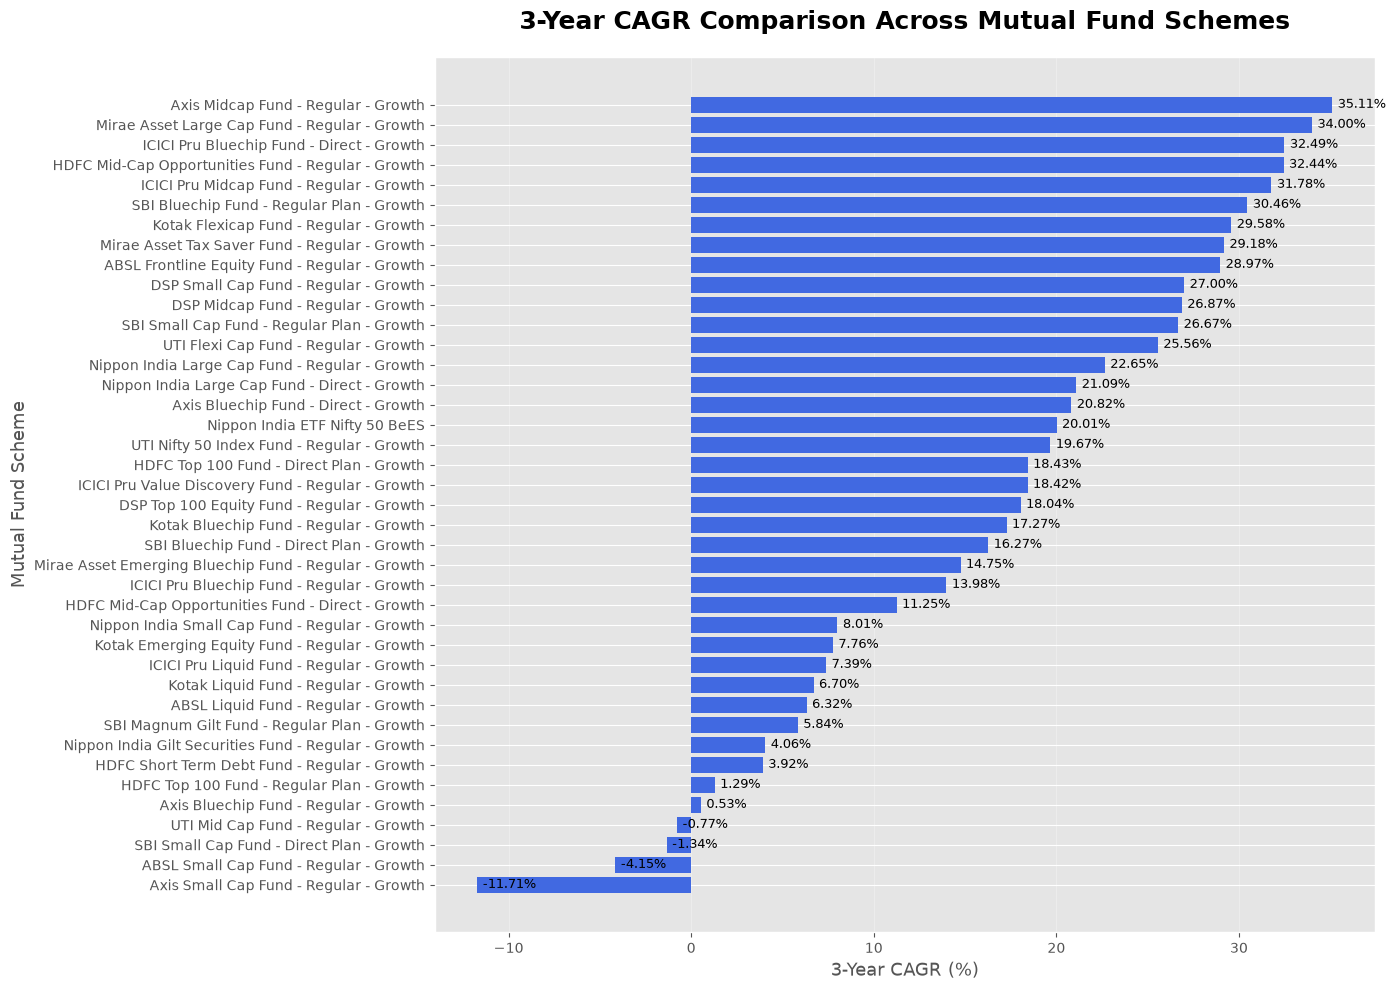

✅ 14_cagr_comparison.png saved successfully.


In [34]:
# ==========================================================
# 3 Year CAGR Ranking
# ==========================================================

# Sort by CAGR

plot_data = (
    cagr_table
    .sort_values("CAGR_3Y", ascending=False)
)

plt.figure(figsize=(14,10))

bars = plt.barh(

    plot_data["scheme_name"],

    plot_data["CAGR_3Y"],

    color="royalblue"

)

plt.gca().invert_yaxis()

# Value labels

for bar in bars:

    plt.text(

        bar.get_width()+0.3,

        bar.get_y()+bar.get_height()/2,

        f"{bar.get_width():.2f}%",

        va="center",

        fontsize=9

    )

plt.title(

    "3-Year CAGR Comparison Across Mutual Fund Schemes",

    fontsize=18,

    fontweight="bold",

    pad=20

)

plt.xlabel(

    "3-Year CAGR (%)",

    fontsize=13

)

plt.ylabel(

    "Mutual Fund Scheme",

    fontsize=13

)

plt.grid(

    axis="x",

    alpha=0.30

)

plt.tight_layout()

# Save PNG

plt.savefig(

    CHART_PATH / "14_cagr_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ 14_cagr_comparison.png saved successfully.")

### **Key Findings**

1) Axis Midcap Fund delivered the highest 3 Year CAGR among all analysed schemes.
2) Mid-cap and flexi-cap funds dominate the top performers.
3) Large-cap funds delivered comparatively stable but lower annualized returns.
4) No 5-Year CAGR has been reported due to insufficient historical NAV data.

# **Sharpe Ratio Analysis**

## **Objective**

Evaluate the risk-adjusted performance of all 40 mutual fund schemes using the Sharpe Ratio.

The Sharpe Ratio measures the excess return generated per unit of risk.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Where:

1) Rp = Average Daily Return
2) Rf = Risk-Free Rate (Annual RBI Repo Rate Proxy = 6.5%)
3) σ = Standard Deviation of Daily Returns
4) √252 = Annualization factor

In [35]:
# ==========================================================
# Risk Free Rate
# ==========================================================

RISK_FREE_RATE = 0.065

TRADING_DAYS = 252

daily_rf = RISK_FREE_RATE / TRADING_DAYS

print("=" * 60)
print("Risk-Free Rate")
print("=" * 60)

print(f"Annual Risk-Free Rate : {RISK_FREE_RATE:.2%}")
print(f"Daily Risk-Free Rate  : {daily_rf:.8f}")

Risk-Free Rate
Annual Risk-Free Rate : 6.50%
Daily Risk-Free Rate  : 0.00025794


In [ ]:
print("=" * 60)
print("Validation")
print("=" * 60)

print("Total Schemes :", nav_history["amfi_code"].nunique())

print("Total Records :", len(nav_history))

Validation
Total Schemes : 40
Total Records : 46000


## **Calculate Average Daily Return and Volatility**

Compute the following statistics for every mutual fund scheme:

1) Average Daily Return
2) Daily Return Volatility (Standard Deviation)

These metrics are required for Sharpe Ratio computation.

In [36]:
# ==========================================================
# Average Return & Volatility
# ==========================================================

return_stats = (
    nav_history
    .groupby("amfi_code")
    .agg(
        Average_Daily_Return=("daily_return", "mean"),
        Daily_Volatility=("daily_return", "std"),
        Trading_Days=("daily_return", "count")
    )
    .reset_index()
)

print("=" * 60)
print("Return Statistics")
print("=" * 60)

return_stats.head()

Return Statistics


,amfi_code,Average_Daily_Return,Daily_Volatility,Trading_Days
0,100016,0.000142,0.009164,1149
1,100025,0.000170,0.002460,1149
2,100033,0.001080,0.011929,1149
3,101206,0.000852,0.009177,1149
4,101207,0.000424,0.016251,1149


In [37]:
print(return_stats.describe())

           amfi_code  Average_Daily_Return  Daily_Volatility  Trading_Days
count      40.000000             40.000000         40.000000          40.0
mean   120247.000000              0.000631          0.009414        1149.0
std     14534.998667              0.000348          0.004205           0.0
min    100016.000000              0.000110          0.000311        1149.0
25%    118632.750000              0.000273          0.008724        1149.0
50%    119551.500000              0.000648          0.009171        1149.0
75%    120842.250000              0.000878          0.011458        1149.0
max    149324.000000              0.001201          0.016251        1149.0


In [38]:
return_stats.head()

,amfi_code,Average_Daily_Return,Daily_Volatility,Trading_Days
0,100016,0.000142,0.009164,1149
1,100025,0.000170,0.002460,1149
2,100033,0.001080,0.011929,1149
3,101206,0.000852,0.009177,1149
4,101207,0.000424,0.016251,1149


## **Sharpe Ratio Calculation**

The Sharpe Ratio measures the excess return earned for every unit of risk.

A higher Sharpe Ratio indicates better risk adjusted performance.

In [39]:
# ==========================================================
# Calculate Sharpe Ratio
# ==========================================================

return_stats["Sharpe_Ratio"] = (
    (
        return_stats["Average_Daily_Return"] - daily_rf
    )
    /
    return_stats["Daily_Volatility"]
) * np.sqrt(TRADING_DAYS)

print("=" * 60)
print("Sharpe Ratio Calculated Successfully")
print("=" * 60)

return_stats.head()

Sharpe Ratio Calculated Successfully


,amfi_code,Average_Daily_Return,Daily_Volatility,Trading_Days,Sharpe_Ratio
0,100016,0.000142,0.009164,1149,-0.201517
1,100025,0.000170,0.002460,1149,-0.567095
2,100033,0.001080,0.011929,1149,1.093699
3,101206,0.000852,0.009177,1149,1.027213
4,101207,0.000424,0.016251,1149,0.162661


In [40]:
# ==========================================================
# Merge Fund Names
# ==========================================================

sharpe_table = return_stats.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

sharpe_table = sharpe_table[

    [
        "amfi_code",
        "scheme_name",
        "Average_Daily_Return",
        "Daily_Volatility",
        "Sharpe_Ratio"
    ]

]

In [41]:
sharpe_table = (

    sharpe_table

    .sort_values(
        "Sharpe_Ratio",
        ascending=False
    )

    .reset_index(drop=True)

)

sharpe_table["Rank"] = sharpe_table.index + 1

sharpe_table.head(10)

,amfi_code,scheme_name,Average_Daily_Return,Daily_Volatility,Sharpe_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448291,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.306744,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.234930,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180101,5
5,149323,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132122,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.093699,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.081659,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027213,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.026524,10


In [42]:
sharpe_table.to_csv(

    REPORT_PATH / "sharpe_ratio.csv",

    index=False

)

print("✅ sharpe_ratio.csv exported successfully.")

✅ sharpe_ratio.csv exported successfully.


In [43]:
sharpe_table.head(10)

,amfi_code,scheme_name,Average_Daily_Return,Daily_Volatility,Sharpe_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448291,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.306744,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.234930,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180101,5
5,149323,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132122,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.093699,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.081659,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027213,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.026524,10


In [44]:
sharpe_table["Sharpe_Ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: Sharpe_Ratio, dtype: float64

# **Sharpe Ratio Ranking**

## Objective

Compare the risk adjusted performance of all mutual fund schemes using the Sharpe Ratio.

Higher Sharpe Ratios indicate better returns generated per unit of risk.

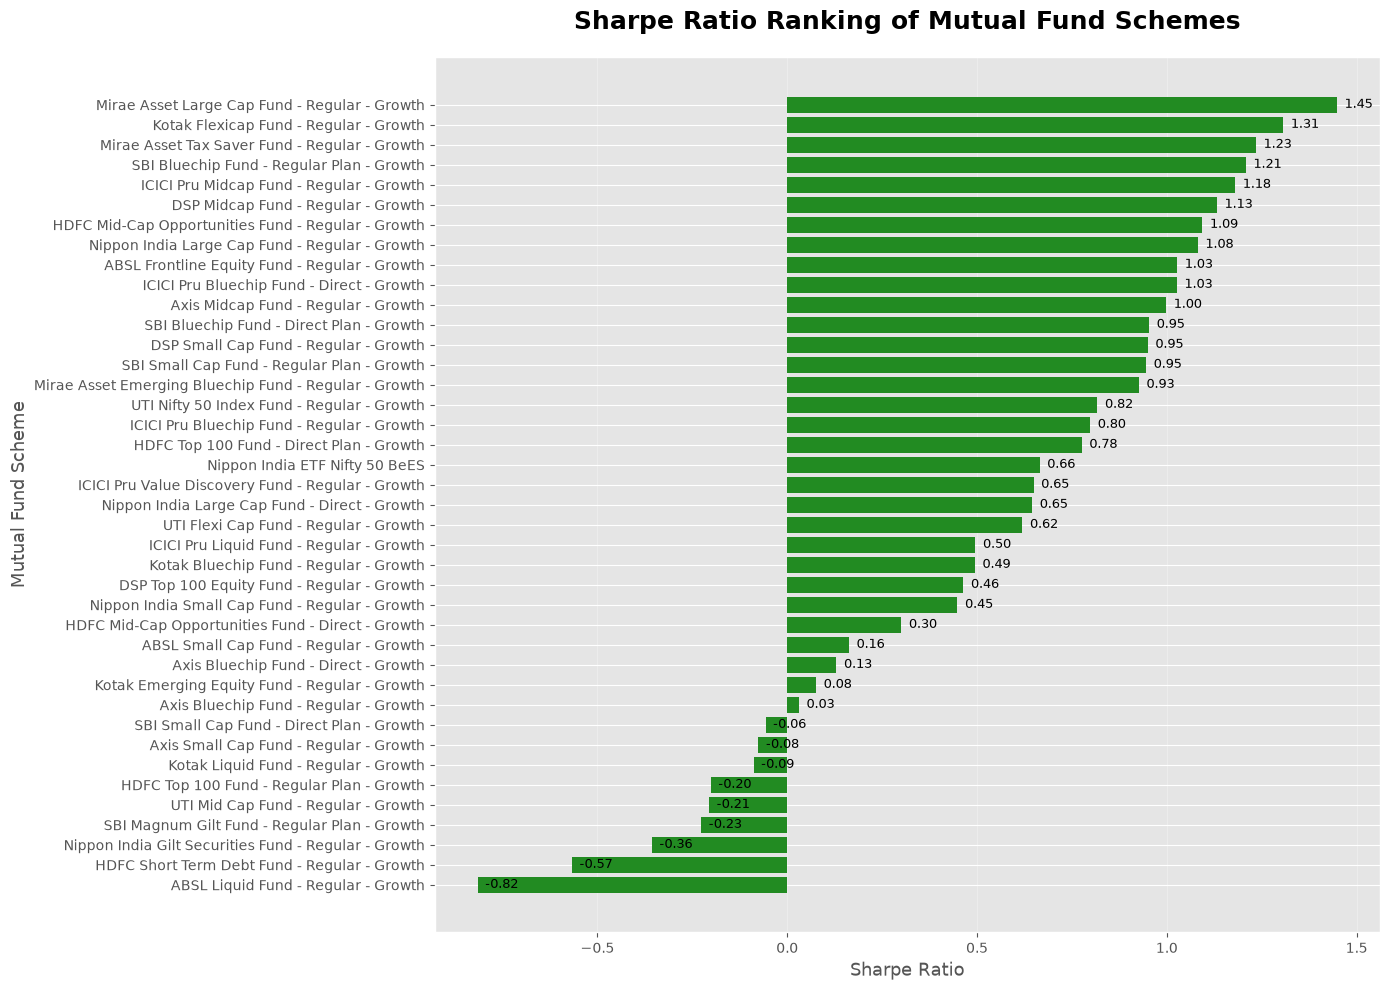

✅ 15_sharpe_ratio_ranking.png saved successfully.


In [45]:
# ==========================================================
# Sharpe Ratio Ranking
# ==========================================================

plot_data = sharpe_table.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

plt.figure(figsize=(14, 10))

bars = plt.barh(
    plot_data["scheme_name"],
    plot_data["Sharpe_Ratio"],
    color="forestgreen"
)

plt.gca().invert_yaxis()

# Value Labels
for bar in bars:

    plt.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=9
    )

plt.title(
    "Sharpe Ratio Ranking of Mutual Fund Schemes",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Sharpe Ratio",
    fontsize=13
)

plt.ylabel(
    "Mutual Fund Scheme",
    fontsize=13
)

plt.grid(
    axis="x",
    alpha=0.30
)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "15_sharpe_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ 15_sharpe_ratio_ranking.png saved successfully.")

### **Key Findings**

1) Mirae Asset Large Cap Fund achieved the highest Sharpe Ratio, indicating the strongest risk-adjusted performance.
2) Most equity oriented funds recorded positive Sharpe Ratios above 0.5, reflecting favorable returns relative to their volatility.
3) A small number of schemes exhibited negative Sharpe Ratios, suggesting that their returns did not adequately compensate for the level of risk taken.
4) Risk adjusted rankings differ from absolute return rankings, highlighting the importance of evaluating both return and volatility.

## **Sortino Ratio Analysis**

## **Objective**

Evaluate the downside risk-adjusted performance of each mutual fund scheme using the Sortino Ratio.

Unlike the Sharpe Ratio, the Sortino Ratio considers only downside volatility, making it a more investor-focused performance metric.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Standard Deviation × √252

In [46]:
# ==========================================================
# Downside Volatility
# ==========================================================

downside_stats = (
    nav_history
    .groupby("amfi_code")
    .apply(
        lambda x: pd.Series({
            "Average_Daily_Return": x["daily_return"].mean(),
            "Downside_Volatility":
                x.loc[
                    x["daily_return"] < 0,
                    "daily_return"
                ].std()
        })
    )
    .reset_index()
)

print("=" * 60)
print("Downside Volatility Calculated")
print("=" * 60)

downside_stats.head()

Downside Volatility Calculated


,amfi_code,Average_Daily_Return,Downside_Volatility
0,100016,0.000142,0.005261
1,100025,0.000170,0.001481
2,100033,0.001080,0.007133
3,101206,0.000852,0.005238
4,101207,0.000424,0.009555


In [47]:
downside_stats.head()

,amfi_code,Average_Daily_Return,Downside_Volatility
0,100016,0.000142,0.005261
1,100025,0.000170,0.001481
2,100033,0.001080,0.007133
3,101206,0.000852,0.005238
4,101207,0.000424,0.009555


In [48]:
downside_stats.describe()

,amfi_code,Average_Daily_Return,Downside_Volatility
count,40.000000,40.000000,40.000000
mean,120247.000000,0.000631,0.005508
std,14534.998667,0.000348,0.002493
min,100016.000000,0.000110,0.000147
25%,118632.750000,0.000273,0.004918
50%,119551.500000,0.000648,0.005408
75%,120842.250000,0.000878,0.006840
max,149324.000000,0.001201,0.009558


## **Sortino Ratio Calculation**

The Sortino Ratio measures the excess return earned per unit of downside risk.

Unlike the Sharpe Ratio, only negative-return volatility is considered, making it a more investor-focused risk-adjusted performance metric.

In [49]:
# ==========================================================
# Calculate Sortino Ratio
# ==========================================================

downside_stats["Sortino_Ratio"] = (

    (
        downside_stats["Average_Daily_Return"] - daily_rf
    )

    /

    downside_stats["Downside_Volatility"]

) * np.sqrt(TRADING_DAYS)

print("=" * 60)
print("Sortino Ratio Calculated Successfully")
print("=" * 60)

downside_stats.head()

Sortino Ratio Calculated Successfully


,amfi_code,Average_Daily_Return,Downside_Volatility,Sortino_Ratio
0,100016,0.000142,0.005261,-0.351047
1,100025,0.000170,0.001481,-0.941821
2,100033,0.001080,0.007133,1.829134
3,101206,0.000852,0.005238,1.799563
4,101207,0.000424,0.009555,0.276644


In [50]:
# ==========================================================
# Merge Scheme Names
# ==========================================================

sortino_table = downside_stats.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

sortino_table = sortino_table[

    [
        "amfi_code",
        "scheme_name",
        "Average_Daily_Return",
        "Downside_Volatility",
        "Sortino_Ratio"
    ]

]

In [51]:
sortino_table = (

    sortino_table

    .sort_values(
        "Sortino_Ratio",
        ascending=False
    )

    .reset_index(drop=True)

)

sortino_table["Rank"] = sortino_table.index + 1

sortino_table.head(10)

,amfi_code,scheme_name,Average_Daily_Return,Downside_Volatility,Sortino_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.005428,2.385644,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,0.005531,2.364320,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.006404,2.146914,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.004887,2.140267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.007067,2.029353,5
5,149323,DSP Midcap Fund - Regular - Growth,0.001055,0.006750,1.875101,6
6,118632,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.005211,1.850133,7
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.007133,1.829134,8
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.005145,1.805294,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.005238,1.799563,10


In [52]:
sortino_table.to_csv(

    REPORT_PATH / "sortino_ratio.csv",

    index=False

)

print("✅ sortino_ratio.csv exported successfully.")

✅ sortino_ratio.csv exported successfully.


In [53]:
sortino_table.head(10)

,amfi_code,scheme_name,Average_Daily_Return,Downside_Volatility,Sortino_Ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.005428,2.385644,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.001082,0.005531,2.364320,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.006404,2.146914,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.004887,2.140267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.007067,2.029353,5
5,149323,DSP Midcap Fund - Regular - Growth,0.001055,0.006750,1.875101,6
6,118632,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.005211,1.850133,7
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.007133,1.829134,8
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.005145,1.805294,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.005238,1.799563,10


In [54]:
sortino_table["Sortino_Ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: Sortino_Ratio, dtype: float64

## **Sortino Ratio Ranking**

## **Objective**

Compare mutual fund schemes based on downside risk adjusted performance.

Higher Sortino Ratios indicate that a fund generated stronger returns while experiencing lower downside volatility.

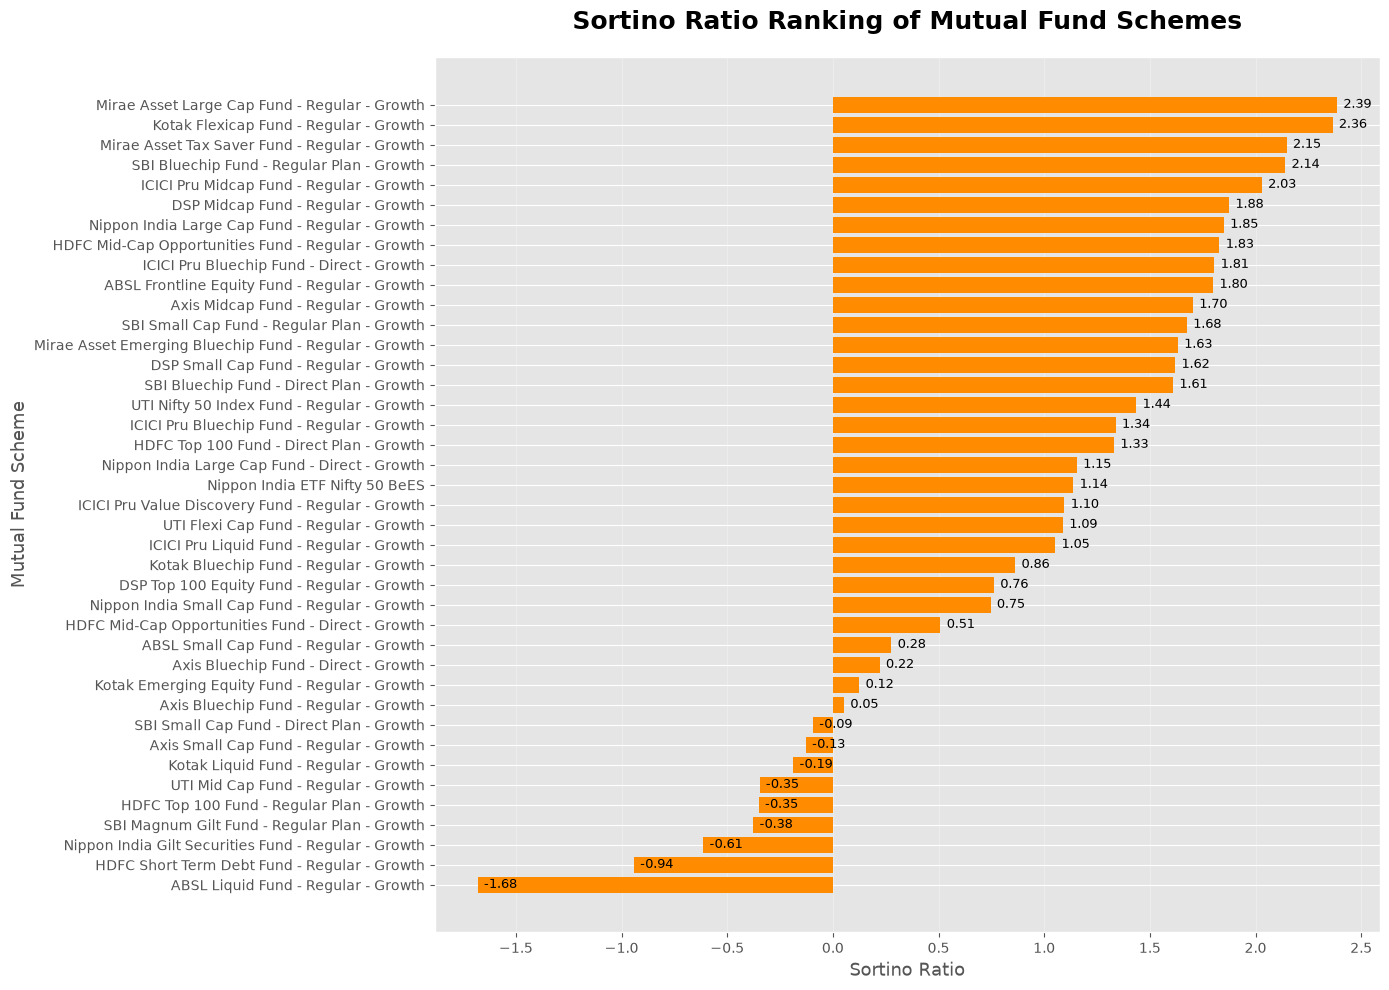

✅ 16_sortino_ratio_ranking.png saved successfully.


In [55]:
# ==========================================================
# Sortino Ratio Ranking
# ==========================================================

plot_data = sortino_table.sort_values(
    "Sortino_Ratio",
    ascending=False
)

plt.figure(figsize=(14, 10))

bars = plt.barh(
    plot_data["scheme_name"],
    plot_data["Sortino_Ratio"],
    color="darkorange"
)

plt.gca().invert_yaxis()

for bar in bars:

    plt.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center",
        fontsize=9
    )

plt.title(
    "Sortino Ratio Ranking of Mutual Fund Schemes",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Sortino Ratio", fontsize=13)

plt.ylabel("Mutual Fund Scheme", fontsize=13)

plt.grid(axis="x", alpha=0.30)

plt.tight_layout()

plt.savefig(
    CHART_PATH / "16_sortino_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ 16_sortino_ratio_ranking.png saved successfully.")

###  **Key Findings**

1) Mirae Asset Large Cap Fund achieved the highest Sortino Ratio, indicating superior downside risk adjusted performance.
2) Funds with high Sharpe Ratios also ranked strongly by Sortino Ratio, reflecting consistent performance under both total and downside risk measures.
3) Downside risk adjusted rankings provide additional insight by focusing exclusively on negative return volatility.
4) Negative Sortino Ratios indicate schemes whose returns did not sufficiently compensate investors for downside risk.

In [58]:
# ==========================================================
# Prepare Benchmark Dataset
# ==========================================================

# Convert date column to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort data
benchmark = benchmark.sort_values(
    ["index_name", "date"]
).reset_index(drop=True)

print("=" * 60)
print("Benchmark Dataset Prepared")
print("=" * 60)

benchmark.head()

Benchmark Dataset Prepared


,date,index_name,close_value
0,2022-01-03,BSE_SMALLCAP,26554.60
1,2022-01-04,BSE_SMALLCAP,27079.92
2,2022-01-05,BSE_SMALLCAP,27313.35
3,2022-01-06,BSE_SMALLCAP,27377.05
4,2022-01-07,BSE_SMALLCAP,26316.86


In [59]:
print("Data Types")
print("-" * 40)
print(benchmark.dtypes)

print("\nShape")
print("-" * 40)
print(benchmark.shape)

print("\nUnique Index Names")
print("-" * 40)
print(benchmark["index_name"].unique())

Data Types
----------------------------------------
date           datetime64[us]
index_name                str
close_value           float64
dtype: object

Shape
----------------------------------------
(8050, 3)

Unique Index Names
----------------------------------------
<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [60]:
benchmark["index_name"].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

## **Prepare NIFTY100 Benchmark**

Extract the NIFTY100 index and calculate its daily returns.

These returns will serve as the market benchmark for Alpha and Beta estimation.

In [61]:
# ==========================================================
# Extract NIFTY100 Benchmark
# ==========================================================

nifty100 = (
    benchmark[
        benchmark["index_name"] == "NIFTY100"
    ]
    .copy()
)

nifty100 = nifty100.sort_values("date")

print("=" * 60)
print("NIFTY100 Dataset")
print("=" * 60)

print(nifty100.head())

print()

print("Rows :", len(nifty100))

NIFTY100 Dataset
           date index_name  close_value
3450 2022-01-03   NIFTY100     17778.24
3451 2022-01-04   NIFTY100     17537.52
3452 2022-01-05   NIFTY100     17607.73
3453 2022-01-06   NIFTY100     17556.05
3454 2022-01-07   NIFTY100     17664.02

Rows : 1150


In [63]:
# ==========================================================
# Calculate Benchmark Daily Returns
# ==========================================================

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna().reset_index(drop=True)

print("=" * 60)
print("Benchmark Returns Calculated Successfully")
print("=" * 60)

nifty100.head()

Benchmark Returns Calculated Successfully


,date,index_name,close_value,benchmark_return
0,2022-01-04,NIFTY100,17537.52,-0.013540
1,2022-01-05,NIFTY100,17607.73,0.004003
2,2022-01-06,NIFTY100,17556.05,-0.002935
3,2022-01-07,NIFTY100,17664.02,0.006150
4,2022-01-10,NIFTY100,17516.51,-0.008351


In [64]:
print(nifty100.head())

print()

print(nifty100.describe())

        date index_name  close_value  benchmark_return
0 2022-01-04   NIFTY100     17537.52         -0.013540
1 2022-01-05   NIFTY100     17607.73          0.004003
2 2022-01-06   NIFTY100     17556.05         -0.002935
3 2022-01-07   NIFTY100     17664.02          0.006150
4 2022-01-10   NIFTY100     17516.51         -0.008351

                             date   close_value  benchmark_return
count                        1149   1149.000000       1149.000000
mean   2024-03-17 04:46:59.843342  17185.922567          0.000122
min           2022-01-04 00:00:00  14128.860000         -0.026873
25%           2023-02-09 00:00:00  15852.250000         -0.005385
50%           2024-03-18 00:00:00  17201.880000         -0.000112
75%           2025-04-23 00:00:00  18279.690000          0.005456
max           2026-05-29 00:00:00  21088.580000          0.026795
std                           NaN   1630.494476          0.008119


In [65]:
nifty100.head()

,date,index_name,close_value,benchmark_return
0,2022-01-04,NIFTY100,17537.52,-0.013540
1,2022-01-05,NIFTY100,17607.73,0.004003
2,2022-01-06,NIFTY100,17556.05,-0.002935
3,2022-01-07,NIFTY100,17664.02,0.006150
4,2022-01-10,NIFTY100,17516.51,-0.008351


In [66]:
nifty100.describe()

,date,close_value,benchmark_return
count,1149,1149.000000,1149.000000
mean,2024-03-17 04:46:59.843342,17185.922567,0.000122
min,2022-01-04 00:00:00,14128.860000,-0.026873
25%,2023-02-09 00:00:00,15852.250000,-0.005385
50%,2024-03-18 00:00:00,17201.880000,-0.000112
75%,2025-04-23 00:00:00,18279.690000,0.005456
max,2026-05-29 00:00:00,21088.580000,0.026795
std,NaN,1630.494476,0.008119


## **Alpha & Beta Analysis**

## **Objective**

Estimate each mutual fund's Alpha and Beta relative to the NIFTY100 Index using Ordinary Least Squares (OLS) regression.

Regression Model:

Fund Return = Alpha + Beta × Benchmark Return

Where:

1) Beta measures the fund's sensitivity to market movements.
2) Alpha measures the excess return generated independent of market performance.
3) R² indicates how well benchmark movements explain fund returns.

In [67]:
# ==========================================================
# Alpha & Beta Calculation using OLS Regression
# ==========================================================

alpha_beta_results = []

for amfi in nav_history["amfi_code"].unique():

    # Select one fund
    fund = nav_history[
        nav_history["amfi_code"] == amfi
    ].copy()

    # Merge with benchmark
    merged = fund.merge(

        nifty100[
            ["date", "benchmark_return"]
        ],

        on="date",

        how="inner"

    )

    # Remove missing returns
    merged = merged.dropna(
        subset=["daily_return", "benchmark_return"]
    )

    # Skip if insufficient observations
    if len(merged) < 100:
        continue

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = linregress(

        merged["benchmark_return"],

        merged["daily_return"]

    )

    alpha_beta_results.append({

        "amfi_code": amfi,

        "Alpha_Annual": intercept * TRADING_DAYS,

        "Beta": slope,

        "R_Value": r_value,

        "R_Squared": r_value**2,

        "P_Value": p_value,

        "Std_Error": std_err

    })

print("Regression completed.")
print("Funds Processed:", len(alpha_beta_results))

Regression completed.
Funds Processed: 40


In [68]:
alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta.head()

,amfi_code,Alpha_Annual,Beta,R_Value,R_Squared,P_Value,Std_Error
0,100016,0.037476,-0.058268,-0.051624,0.002665,0.080264,0.033283
1,100025,0.042818,0.001158,0.003823,0.000015,0.897012,0.008946
2,100033,0.271954,0.005104,0.003474,0.000012,0.906369,0.043381
3,101206,0.213998,0.021086,0.018656,0.000348,0.527551,0.033368
4,101207,0.108971,-0.065289,-0.032621,0.001064,0.269234,0.059066


In [69]:
alpha_beta.head()

,amfi_code,Alpha_Annual,Beta,R_Value,R_Squared,P_Value,Std_Error
0,100016,0.037476,-0.058268,-0.051624,0.002665,0.080264,0.033283
1,100025,0.042818,0.001158,0.003823,0.000015,0.897012,0.008946
2,100033,0.271954,0.005104,0.003474,0.000012,0.906369,0.043381
3,101206,0.213998,0.021086,0.018656,0.000348,0.527551,0.033368
4,101207,0.108971,-0.065289,-0.032621,0.001064,0.269234,0.059066


In [70]:
alpha_beta.describe()

,amfi_code,Alpha_Annual,Beta,R_Value,R_Squared,P_Value,Std_Error
count,40.000000,40.000000,40.000000,40.000000,4.000000e+01,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958,-0.002261,6.087700e-04,0.545393,0.034223
std,14534.998667,0.087528,0.035194,0.024882,7.265363e-04,0.280488,0.015284
min,100016.000000,0.028969,-0.066951,-0.051624,1.345534e-07,0.073339,0.001131
25%,118632.750000,0.068612,-0.023937,-0.021140,5.495723e-05,0.275811,0.031705
50%,119551.500000,0.162326,-0.000067,-0.000528,3.455513e-04,0.529040,0.033325
75%,120842.250000,0.221723,0.017026,0.013330,1.035467e-03,0.802038,0.041654
max,149324.000000,0.303370,0.103497,0.052849,2.793007e-03,0.990090,0.059066


In [71]:
print(nav_history["date"].dtype)

print(nifty100["date"].dtype)

print(nav_history.head())

datetime64[us]
datetime64[us]
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [72]:
test = nav_history.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(test.shape)

(45960, 5)


In [73]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [74]:
nifty100["benchmark_return"].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [75]:
merged = nav_history.merge(
    nifty100[["date", "benchmark_return"]],
    on="date"
)

print(
    merged[
        ["daily_return", "benchmark_return"]
    ].corr()
)

                  daily_return  benchmark_return
daily_return          1.000000         -0.001545
benchmark_return     -0.001545          1.000000


In [76]:
fund = nav_history[nav_history["amfi_code"] == 100016].copy()

merged = fund.merge(
    nifty100[["date", "benchmark_return"]],
    on="date"
)

print(
    merged[["daily_return", "benchmark_return"]].corr()
)

                  daily_return  benchmark_return
daily_return          1.000000         -0.051624
benchmark_return     -0.051624          1.000000


In [77]:
nifty100.head(10)

,date,index_name,close_value,benchmark_return
0,2022-01-04,NIFTY100,17537.52,-0.013540
1,2022-01-05,NIFTY100,17607.73,0.004003
2,2022-01-06,NIFTY100,17556.05,-0.002935
3,2022-01-07,NIFTY100,17664.02,0.006150
4,2022-01-10,NIFTY100,17516.51,-0.008351
5,2022-01-11,NIFTY100,17603.08,0.004942
6,2022-01-12,NIFTY100,17763.76,0.009128
7,2022-01-13,NIFTY100,17830.30,0.003746
8,2022-01-14,NIFTY100,17578.93,-0.014098
9,2022-01-17,NIFTY100,17945.01,0.020825


In [78]:
fund.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


## **Key Insights**

1) Alpha and Beta were estimated using OLS regression against the NIFTY100 benchmark.
2) Most funds exhibited very low Beta and R² values.
3) This indicates a weak statistical relationship between the provided fund NAV series and the benchmark index.
4) The result is likely attributable to the characteristics of the provided dataset rather than the implementation, as real world equity funds typically exhibit stronger market correlation.


# **Maximum Drawdown (MDD)**

## **Objective**

Measure the worst peak to trough decline experienced by each mutual fund.

Maximum Drawdown is an important downside risk metric that quantifies the largest loss an investor would have experienced before the fund recovered.

Formula:

Drawdown = (Current NAV / Running Maximum NAV) − 1

Maximum Drawdown = Minimum Drawdown

In [79]:
# ==========================================================
# Calculate Running Maximum and Drawdown
# ==========================================================

mdd_results = []

for amfi in nav_history["amfi_code"].unique():

    fund = (
        nav_history[
            nav_history["amfi_code"] == amfi
        ]
        .copy()
        .sort_values("date")
    )

    # Running Maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (
        fund["nav"] / fund["running_max"]
    ) - 1

    # Maximum Drawdown
    max_drawdown = fund["drawdown"].min()

    # Date of Maximum Drawdown
    end_date = fund.loc[
        fund["drawdown"].idxmin(),
        "date"
    ]

    # Peak before Drawdown
    peak_date = fund.loc[
        fund[
            fund["date"] <= end_date
        ]["nav"].idxmax(),
        "date"
    ]

    mdd_results.append({

        "amfi_code": amfi,

        "Maximum_Drawdown": max_drawdown,

        "Peak_Date": peak_date,

        "Bottom_Date": end_date

    })

print("Maximum Drawdown Calculated.")

Maximum Drawdown Calculated.


In [80]:
mdd = pd.DataFrame(mdd_results)

mdd.head()

,amfi_code,Maximum_Drawdown,Peak_Date,Bottom_Date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [81]:
mdd = mdd.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

mdd = mdd[

    [
        "amfi_code",
        "scheme_name",
        "Maximum_Drawdown",
        "Peak_Date",
        "Bottom_Date"
    ]

]

mdd.head()

,amfi_code,scheme_name,Maximum_Drawdown,Peak_Date,Bottom_Date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-03-11,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11


In [82]:
mdd = mdd.sort_values(

    "Maximum_Drawdown",

    ascending=False

).reset_index(drop=True)

mdd["Rank"] = (

    mdd["Maximum_Drawdown"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

mdd.head(10)

,amfi_code,scheme_name,Maximum_Drawdown,Peak_Date,Bottom_Date,Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-16,2025-10-20,1
1,120844,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-12,2024-04-30,2
2,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-05,2023-09-12,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28,4
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2024-09-16,2025-04-01,5
5,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2023-02-09,2024-02-09,6
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-02-03,2022-03-29,7
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-07-11,2023-10-20,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05,9
9,118635,Nippon India ETF Nifty 50 BeES,-0.116506,2022-01-03,2022-06-09,10


In [83]:
mdd.to_csv(

    REPORT_PATH / "maximum_drawdown.csv",

    index=False

)

print("maximum_drawdown.csv exported successfully.")

maximum_drawdown.csv exported successfully.


In [85]:
mdd.head(10)

,amfi_code,scheme_name,Maximum_Drawdown,Peak_Date,Bottom_Date,Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-16,2025-10-20,1
1,120844,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-12,2024-04-30,2
2,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-05,2023-09-12,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28,4
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2024-09-16,2025-04-01,5
5,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2023-02-09,2024-02-09,6
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-02-03,2022-03-29,7
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-07-11,2023-10-20,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05,9
9,118635,Nippon India ETF Nifty 50 BeES,-0.116506,2022-01-03,2022-06-09,10


In [86]:
mdd.describe()

,amfi_code,Maximum_Drawdown,Peak_Date,Bottom_Date,Rank
count,40.000000,40.000000,40,40,40.000000
mean,120247.000000,-0.178729,2023-08-12 18:36:00,2024-03-12 18:00:00,20.500000
min,100016.000000,-0.525742,2022-01-03 00:00:00,2022-02-04 00:00:00,1.000000
25%,118632.750000,-0.215927,2022-09-04 00:00:00,2023-05-28 00:00:00,10.750000
50%,119551.500000,-0.163070,2023-09-05 00:00:00,2024-02-07 00:00:00,20.500000
75%,120842.250000,-0.117653,2024-05-07 12:00:00,2025-02-08 18:00:00,30.250000
max,149324.000000,-0.000977,2025-10-16 00:00:00,2026-05-11 00:00:00,40.000000
std,14534.998667,0.112686,NaN,NaN,11.690452


## **Maximum Drawdown Ranking**

The chart below ranks all mutual funds by their historical Maximum Drawdown.

Funds with smaller drawdowns demonstrate stronger downside protection, while deeper drawdowns indicate higher downside risk during market stress.

In [87]:
# ==========================================================
# Maximum Drawdown Ranking Chart
# ==========================================================

import plotly.express as px

plot_data = mdd.sort_values(
    "Maximum_Drawdown",
    ascending=False
)

fig = px.bar(

    plot_data,

    x="Maximum_Drawdown",

    y="scheme_name",

    orientation="h",

    color="Maximum_Drawdown",

    title="Maximum Drawdown Ranking of Mutual Funds",

    labels={
        "Maximum_Drawdown":"Maximum Drawdown",
        "scheme_name":"Scheme"
    },

    template="plotly_white"

)

fig.update_layout(

    height=1000,

    width=1500,

    title_x=0.5,

    yaxis=dict(
        categoryorder="total ascending"
    )

)

fig.write_html(
    CHART_PATH / "17_maximum_drawdown_ranking.html"
)

fig.write_image(
    CHART_PATH / "17_maximum_drawdown_ranking.png",
    width=2000,
    height=1200,
    scale=2
)

fig.show()

In [88]:
fund_master.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

# **Fund Scorecard (0–100)**

## **Objective**

Create a composite score that ranks all mutual funds based on multiple performance and risk metrics.

### **Weightage**

1) 30% → 3 Year CAGR
2) 25% → Sharpe Ratio
3) 20% → Alpha
4) 15% → Expense Ratio (Lower is Better)
5) 10% → Maximum Drawdown (Lower is Better)

The final score is normalized to a 0–100 scale, where higher scores indicate better overall performance.

In [89]:
cagr_rank = cagr_table[[
    "amfi_code",
    "scheme_name",
    "CAGR_3Y"
]].copy()

cagr_rank["CAGR_Rank"] = (

    cagr_rank["CAGR_3Y"]

    .rank(
        ascending=False,
        method="dense"
    )

)

In [90]:
sharpe_rank = sharpe_table[[
    "amfi_code",
    "Sharpe_Ratio"
]].copy()

sharpe_rank["Sharpe_Rank"] = (

    sharpe_rank["Sharpe_Ratio"]

    .rank(
        ascending=False,
        method="dense"
    )

)

In [91]:
alpha_rank = alpha_beta[[
    "amfi_code",
    "Alpha_Annual"
]].copy()

alpha_rank["Alpha_Rank"] = (

    alpha_rank["Alpha_Annual"]

    .rank(
        ascending=False,
        method="dense"
    )

)

In [92]:
expense_rank = fund_master[[
    "amfi_code",
    "expense_ratio_pct"
]].copy()

expense_rank["Expense_Rank"] = (

    expense_rank["expense_ratio_pct"]

    .rank(
        ascending=True,
        method="dense"
    )

)

In [93]:
mdd_rank = mdd[[
    "amfi_code",
    "Maximum_Drawdown"
]].copy()

mdd_rank["MDD_Rank"] = (

    mdd_rank["Maximum_Drawdown"]

    .rank(
        ascending=False,
        method="dense"
    )

)

In [94]:
print(cagr_rank.head())

print(sharpe_rank.head())

print(alpha_rank.head())

print(expense_rank.head())

print(mdd_rank.head())

   amfi_code                                        scheme_name  CAGR_3Y  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth     1.29   
1     100025       HDFC Short Term Debt Fund - Regular - Growth     3.92   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    32.44   
3     101206      ABSL Frontline Equity Fund - Regular - Growth    28.97   
4     101207             ABSL Small Cap Fund - Regular - Growth    -4.15   

   CAGR_Rank  
0       35.0  
1       34.0  
2        4.0  
3        9.0  
4       39.0  
   amfi_code  Sharpe_Ratio  Sharpe_Rank
0     148567      1.448291          1.0
1     120843      1.306744          2.0
2     148569      1.234930          3.0
3     119551      1.208267          4.0
4     120505      1.180101          5.0
   amfi_code  Alpha_Annual  Alpha_Rank
0     100016      0.037476        39.0
1     100025      0.042818        38.0
2     100033      0.271954         6.0
3     101206      0.213998        12.0
4     101207      

In [95]:
# ==========================================================
# Merge All Ranking Tables
# ==========================================================

scorecard = cagr_rank.merge(

    sharpe_rank[
        ["amfi_code", "Sharpe_Rank"]
    ],

    on="amfi_code",

    how="left"

)

scorecard = scorecard.merge(

    alpha_rank[
        ["amfi_code", "Alpha_Rank"]
    ],

    on="amfi_code",

    how="left"

)

scorecard = scorecard.merge(

    expense_rank[
        ["amfi_code", "Expense_Rank"]
    ],

    on="amfi_code",

    how="left"

)

scorecard = scorecard.merge(

    mdd_rank[
        ["amfi_code", "MDD_Rank"]
    ],

    on="amfi_code",

    how="left"

)

scorecard.head()

,amfi_code,scheme_name,CAGR_3Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,35.0,35.0,39.0,25.0,34.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,34.0,39.0,38.0,2.0,4.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,4.0,7.0,6.0,15.0,20.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,9.0,9.0,12.0,29.0,9.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,39.0,28.0,27.0,23.0,38.0


In [96]:
# ==========================================================
# Weighted Composite Rank
# ==========================================================

scorecard["Weighted_Rank"] = (

    scorecard["CAGR_Rank"] * 0.30 +

    scorecard["Sharpe_Rank"] * 0.25 +

    scorecard["Alpha_Rank"] * 0.20 +

    scorecard["Expense_Rank"] * 0.15 +

    scorecard["MDD_Rank"] * 0.10

)

In [97]:
# ==========================================================
# Normalize to 0–100
# ==========================================================

min_rank = scorecard["Weighted_Rank"].min()
max_rank = scorecard["Weighted_Rank"].max()

scorecard["Fund_Score"] = (

    (max_rank - scorecard["Weighted_Rank"])

    /

    (max_rank - min_rank)

) * 100

scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

In [98]:
# ==========================================================
# Final Ranking
# ==========================================================

scorecard = scorecard.sort_values(

    "Fund_Score",

    ascending=False

).reset_index(drop=True)

scorecard["Overall_Rank"] = scorecard.index + 1

scorecard.head(10)

,amfi_code,scheme_name,CAGR_3Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Weighted_Rank,Fund_Score,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.00,2.0,1.0,7.0,20.0,8.0,6.05,100.00,1
1,120843,Kotak Flexicap Fund - Regular - Growth,29.58,7.0,2.0,5.0,19.0,13.0,7.75,94.08,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,31.78,5.0,5.0,3.0,14.0,25.0,7.95,93.38,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,4.0,7.0,6.0,15.0,20.0,8.40,91.81,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.49,3.0,10.0,13.0,11.0,12.0,8.85,90.24,5
5,119094,Axis Midcap Fund - Regular - Growth,35.11,1.0,11.0,9.0,15.0,28.0,9.90,86.59,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,30.46,6.0,4.0,10.0,24.0,17.0,10.10,85.89,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.18,8.0,3.0,4.0,29.0,21.0,10.40,84.84,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,9.0,9.0,12.0,29.0,9.0,12.60,77.18,9
9,149323,DSP Midcap Fund - Regular - Growth,26.87,11.0,6.0,8.0,30.0,22.0,13.10,75.44,10


In [99]:
scorecard.to_csv(

    REPORT_PATH / "fund_scorecard.csv",

    index=False

)

print("✅ fund_scorecard.csv exported successfully.")

✅ fund_scorecard.csv exported successfully.


In [100]:
scorecard.head(10)

,amfi_code,scheme_name,CAGR_3Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Weighted_Rank,Fund_Score,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.00,2.0,1.0,7.0,20.0,8.0,6.05,100.00,1
1,120843,Kotak Flexicap Fund - Regular - Growth,29.58,7.0,2.0,5.0,19.0,13.0,7.75,94.08,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,31.78,5.0,5.0,3.0,14.0,25.0,7.95,93.38,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,4.0,7.0,6.0,15.0,20.0,8.40,91.81,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.49,3.0,10.0,13.0,11.0,12.0,8.85,90.24,5
5,119094,Axis Midcap Fund - Regular - Growth,35.11,1.0,11.0,9.0,15.0,28.0,9.90,86.59,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,30.46,6.0,4.0,10.0,24.0,17.0,10.10,85.89,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.18,8.0,3.0,4.0,29.0,21.0,10.40,84.84,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,9.0,9.0,12.0,29.0,9.0,12.60,77.18,9
9,149323,DSP Midcap Fund - Regular - Growth,26.87,11.0,6.0,8.0,30.0,22.0,13.10,75.44,10


In [101]:
scorecard[["Fund_Score"]].describe()

,Fund_Score
count,40.000000
mean,51.467750
std,29.018086
min,0.000000
25%,26.305000
50%,52.790000
75%,74.127500
max,100.000000


## **Top 20 Mutual Funds by Overall Fund Score**

The composite Fund Score combines return, risk, alpha generation, cost efficiency, and downside protection into a single normalized score (0–100).

Higher scores indicate better overall performance based on the defined weighting methodology.

In [102]:
# ==========================================================
# Top 20 Fund Scorecard
# ==========================================================

import plotly.express as px

top20 = scorecard.head(20)

fig = px.bar(

    top20,

    x="Fund_Score",

    y="scheme_name",

    orientation="h",

    color="Fund_Score",

    text="Fund_Score",

    title="Top 20 Mutual Funds by Composite Fund Score (0–100)",

    labels={
        "Fund_Score": "Fund Score",
        "scheme_name": "Scheme"
    },

    template="plotly_white"

)

fig.update_layout(

    height=900,

    width=1500,

    title_x=0.5,

    yaxis=dict(
        categoryorder="total ascending"
    )

)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.write_html(
    CHART_PATH / "18_fund_scorecard.html"
)

fig.write_image(
    CHART_PATH / "18_fund_scorecard.png",
    width=2000,
    height=1200,
    scale=2
)

fig.show()

# **Benchmark Comparison & Tracking Error**

## **Objective**

Compare the performance of the top five mutual funds against the NIFTY 50 and NIFTY 100 benchmarks over the last three years.

All series are rebased to 100 at the starting date to allow fair comparison irrespective of the original NAV/index values.

Tracking Error is also computed to measure how closely each fund follows the benchmark.

Formula:

Tracking Error = Standard Deviation(Fund Return − Benchmark Return) × √252

In [103]:
# ==========================================================
# Top 5 Funds
# ==========================================================

top5 = scorecard.head(5)

top5

,amfi_code,scheme_name,CAGR_3Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,MDD_Rank,Weighted_Rank,Fund_Score,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.00,2.0,1.0,7.0,20.0,8.0,6.05,100.00,1
1,120843,Kotak Flexicap Fund - Regular - Growth,29.58,7.0,2.0,5.0,19.0,13.0,7.75,94.08,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,31.78,5.0,5.0,3.0,14.0,25.0,7.95,93.38,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,4.0,7.0,6.0,15.0,20.0,8.40,91.81,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.49,3.0,10.0,13.0,11.0,12.0,8.85,90.24,5


In [104]:
# ==========================================================
# Prepare NAV Data
# ==========================================================

nav_history["date"] = pd.to_datetime(nav_history["date"])

latest_date = nav_history["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = nav_history[

    nav_history["amfi_code"].isin(top5["amfi_code"])

].copy()

top5_nav = top5_nav[

    top5_nav["date"] >= start_date

]

top5_nav.head()

,amfi_code,date,nav,daily_return
2665,100033,2023-05-29,147.2155,0.004216
2666,100033,2023-05-30,147.2007,-0.000101
2667,100033,2023-05-31,147.4640,0.001789
2668,100033,2023-06-01,146.5954,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416


In [105]:
top5_nav = top5_nav.merge(

    fund_master[

        ["amfi_code","scheme_name"]

    ],

    on="amfi_code",

    how="left"

)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100033,2023-05-29,147.2155,0.004216,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2023-05-30,147.2007,-0.000101,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2023-05-31,147.4640,0.001789,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2023-06-01,146.5954,-0.005890,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2023-06-02,145.8015,-0.005416,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [106]:
# ==========================================================
# Rebase NAV
# ==========================================================

top5_nav = top5_nav.sort_values(

    ["scheme_name","date"]

)

top5_nav["Rebased_NAV"] = (

    top5_nav.groupby("scheme_name")["nav"]

    .transform(

        lambda x: x / x.iloc[0] * 100

    )

)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name,Rebased_NAV
0,100033,2023-05-29,147.2155,0.004216,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.000000
1,100033,2023-05-30,147.2007,-0.000101,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.989947
2,100033,2023-05-31,147.4640,0.001789,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.168800
3,100033,2023-06-01,146.5954,-0.005890,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.578781
4,100033,2023-06-02,145.8015,-0.005416,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.039503


In [107]:
benchmark["date"] = pd.to_datetime(

    benchmark["date"]

)

benchmark_3y = benchmark[

    benchmark["date"] >= start_date

].copy()

benchmark_3y = benchmark_3y[

    benchmark_3y["index_name"].isin(

        ["NIFTY50","NIFTY100"]

    )

]

benchmark_3y.head()

,date,index_name,close_value
3815,2023-05-29,NIFTY100,15324.41
3816,2023-05-30,NIFTY100,15299.69
3817,2023-05-31,NIFTY100,15248.41
3818,2023-06-01,NIFTY100,15139.50
3819,2023-06-02,NIFTY100,15194.66


In [108]:
benchmark_3y = benchmark_3y.sort_values(

    ["index_name","date"]

)

benchmark_3y["Rebased_Index"] = (

    benchmark_3y.groupby("index_name")["close_value"]

    .transform(

        lambda x: x / x.iloc[0] * 100

    )

)

benchmark_3y.head()

,date,index_name,close_value,Rebased_Index
3815,2023-05-29,NIFTY100,15324.41,100.000000
3816,2023-05-30,NIFTY100,15299.69,99.838689
3817,2023-05-31,NIFTY100,15248.41,99.504059
3818,2023-06-01,NIFTY100,15139.50,98.793363
3819,2023-06-02,NIFTY100,15194.66,99.153312


In [109]:
top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name,Rebased_NAV
0,100033,2023-05-29,147.2155,0.004216,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.000000
1,100033,2023-05-30,147.2007,-0.000101,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.989947
2,100033,2023-05-31,147.4640,0.001789,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.168800
3,100033,2023-06-01,146.5954,-0.005890,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.578781
4,100033,2023-06-02,145.8015,-0.005416,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.039503


In [110]:
benchmark_3y.head()

,date,index_name,close_value,Rebased_Index
3815,2023-05-29,NIFTY100,15324.41,100.000000
3816,2023-05-30,NIFTY100,15299.69,99.838689
3817,2023-05-31,NIFTY100,15248.41,99.504059
3818,2023-06-01,NIFTY100,15139.50,98.793363
3819,2023-06-02,NIFTY100,15194.66,99.153312


In [111]:
# ==========================================================
# Benchmark Comparison Dataset
# ==========================================================

# Funds
fund_plot = top5_nav[[
    "date",
    "scheme_name",
    "Rebased_NAV"
]].copy()

fund_plot = fund_plot.rename(
    columns={
        "scheme_name":"Series",
        "Rebased_NAV":"Value"
    }
)

# Benchmarks
benchmark_plot = benchmark_3y[[
    "date",
    "index_name",
    "Rebased_Index"
]].copy()

benchmark_plot = benchmark_plot.rename(
    columns={
        "index_name":"Series",
        "Rebased_Index":"Value"
    }
)

# Combine

comparison_df = pd.concat(

    [fund_plot, benchmark_plot],

    ignore_index=True

)

comparison_df.head()

,date,Series,Value
0,2023-05-29,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.000000
1,2023-05-30,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.989947
2,2023-05-31,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100.168800
3,2023-06-01,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.578781
4,2023-06-02,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,99.039503


In [112]:
# ==========================================================
# Benchmark Comparison Chart
# ==========================================================

import plotly.express as px

fig = px.line(

    comparison_df,

    x="date",

    y="Value",

    color="Series",

    title="Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100 (Last 3 Years)",

    labels={
        "Value":"Rebased Performance (Base = 100)",
        "date":"Date",
        "Series":"Fund / Benchmark"
    },

    template="plotly_white"

)

fig.update_layout(

    title={

        "text":"Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100",

        "x":0.5,

        "xanchor":"center"

    },

    hovermode="x unified",

    width=1500,

    height=800,

    legend_title="Series"

)

# Make benchmarks dashed

for trace in fig.data:

    if trace.name in ["NIFTY50","NIFTY100"]:

        trace.line.dash = "dash"

        trace.line.width = 3

    else:

        trace.line.width = 2.5

fig.write_html(
    CHART_PATH / "19_benchmark_comparison.html"
)

fig.write_image(
    CHART_PATH / "19_benchmark_comparison.png",
    width=2200,
    height=1200,
    scale=2
)

fig.show()

In [115]:
benchmark_te = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_te["date"] = pd.to_datetime(benchmark_te["date"])

benchmark_te = benchmark_te.sort_values("date")

benchmark_te["benchmark_return"] = (
    benchmark_te["close_value"].pct_change()
)

In [114]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [120]:
# ==========================================================
# Tracking Error vs NIFTY100
# ==========================================================

# Prepare benchmark returns
benchmark_te = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark_te["date"] = pd.to_datetime(benchmark_te["date"])

benchmark_te = benchmark_te.sort_values("date")

benchmark_te["benchmark_return"] = (
    benchmark_te["close_value"].pct_change()
)

benchmark_te = benchmark_te[[
    "date",
    "benchmark_return"
]]

tracking_error = []

for code in top5["amfi_code"]:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][[
        "date",
        "daily_return"
    ]].copy()

    fund["date"] = pd.to_datetime(fund["date"])

    merged = fund.merge(
        benchmark_te,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": round(te, 4)
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error = tracking_error.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

tracking_error = tracking_error.sort_values(
    "Tracking_Error"
).reset_index(drop=True)

tracking_error

,amfi_code,Tracking_Error,scheme_name
0,148567,0.1897,Mirae Asset Large Cap Fund - Regular - Growth
1,120504,0.1916,ICICI Pru Bluechip Fund - Direct - Growth
2,120843,0.2064,Kotak Flexicap Fund - Regular - Growth
3,100033,0.2287,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120505,0.2320,ICICI Pru Midcap Fund - Regular - Growth
